In [2]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import f1_score

import matplotlib.pyplot as plt

/kaggle/input/snotel-data-alldata-morecolumns/snotel_data_alldata_morecolumns.csv


In [3]:
file_path = "/kaggle/input/snotel-data-alldata-morecolumns/snotel_data_alldata_morecolumns.csv"
data = pd.read_csv(file_path)

data['Date'] = pd.to_datetime(data['Date'])
#data['dayofyear'] = data['Date'].dt.dayofyear
data['month'] = data['Date'].dt.month

drop_columns = {'Date','site_name','state','site',
               'Snow Rain Ratio','SWE Max (in)','Snow Density SoD (pct)'}

data=data.drop(columns=drop_columns)

drop_every = 10
data = data.iloc[::drop_every]
data.drop_duplicates(inplace=True) # drop the duplicate rows
data.dropna(inplace=True) # drop any rows that have NA values

data["SWE (in)"].max()

121.7

In [ ]:

for col in ['SWE (in)', 'Depth SoD (in)', 'Precip Inc (in)']:
    data[col] = np.log1p(data[col])

     range  counts
0    0-0.5  162918
1  2.0-2.5   35277
2  2.5-3.0   31072
3  1.5-2.0   28059
4  1.0-1.5   19717
5  3.0-3.5   18693
6  0.5-1.0   15433
7  3.5-4.0    6680
8  4.0-4.5    1071
9  4.5-5.0      48


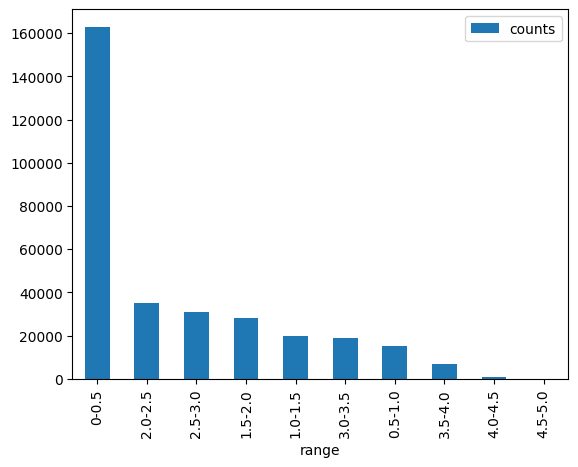

In [3]:
# This is our code for cutting up the continuous classes into bins
def generate_bins(increment):
    bins = []
    i = 0
    while i <= 5:
        bins.append(i)
        i += increment
    return bins

bins = generate_bins(0.5)
bin_labels = []
for i in range(len(bins) - 1):
    label = str(bins[i]) + "-" + str(bins[i+1])
    bin_labels.append(label)

def add_labels(df, bins, bin_labels, column):
    df['range'] = pd.cut(df[column], bins=bins, labels=bin_labels, right=False)
    return df

# Visualize the number in our pseudo classes
temp = add_labels(data, bins, bin_labels, "SWE (in)")
range_counts = temp['range'].value_counts().reset_index()
range_counts.columns = ['range', 'counts']
range_counts.sort_values(by="range")
print(range_counts)

range_counts.plot(x='range', y='counts', kind='bar')
plt.show()

In [4]:
print(np.std(range_counts["counts"]))
print(np.mean(range_counts["counts"]))

45152.626930888524
31896.8


In [5]:
# Upsampling and downsampling CANNOT affect our test set; can't use standard train_test_split
t_s = 0.2

# Do feature transformation before sampling
categorical_features = [' lat','lon']
continuous_features = ['month','Precip Accum SoD (in)','Air Temp Avg (F)','Air Temp Max (F)','Air Temp Obs SoD (F)','Air Temp Min (F)',
                'Precip Month-to-Date SoD (in)','Precip Inc (in)','Depth SoD (in)','Precip Inc Snow-adj (in)']

for feature in categorical_features:
    le = LabelEncoder()
    data[feature] = le.fit_transform(data[feature])

# Currently sampling completely agnostic to our data distribution . . . that may change
# test_df = data.sample(frac=t_s, random_state=42)
# train_df = data.drop(test_df.index)

# test set generated across 'bins'
testing_dfs = []
training_dfs = []

# Upsample strategy: (standard_deviation/bin_count) gives us number needed to duplicate each row
# Divide by number of bins
# Ceiling of 50 rows duplicated (arbitrary ceiling, admittedly)
upsampling = True
downsampling = True
ceiling = 25

standard_deviation = np.std(range_counts["counts"]) * (1-t_s) #adjust for sampling

for bin_label in bin_labels:
    filtered_df = data[data['range'] == bin_label]
    temp_test = filtered_df.sample(frac=t_s, random_state=42)
    testing_dfs.append(temp_test)
    
    # Time to upsample!!
    temp_train = filtered_df.drop(temp_test.index)

    if upsampling:
        num_rows = temp_train.shape[0]
        ratio = standard_deviation/num_rows
        if ratio > 1: # if the ratio is greater than 1, then we know it's one we need to upsample
            # if ratio < ceiling: # set a ceiling limit on upsampling
            duplication_num = round(ratio) 
            # else:
            #     duplication_num = ceiling
            upsampled_train = pd.concat([temp_train]*duplication_num, ignore_index=True)
            training_dfs.append(upsampled_train)
        else: # otherwise, we downsample by a standard deviation
            if downsampling:
                downsample_fraction = 1 - ratio
                print(downsample_fraction)
                downsampled_train = temp_train.sample(frac=downsample_fraction, random_state=41)
                training_dfs.append(downsampled_train)
            else:
                training_dfs.append(temp_train)
                
    else:
        training_dfs.append(temp_train)

test_df = pd.concat(testing_dfs)
train_df = pd.concat(training_dfs)

0.7228497433922781


     range  counts
0    0-0.5   94212
1  1.5-2.0   44894
2  3.5-4.0   37408
3  0.5-1.0   37038
4  4.5-5.0   36138
5  4.0-4.5   35994
6  1.0-1.5   31548
7  3.0-3.5   29908
8  2.0-2.5   28222
9  2.5-3.0   24858


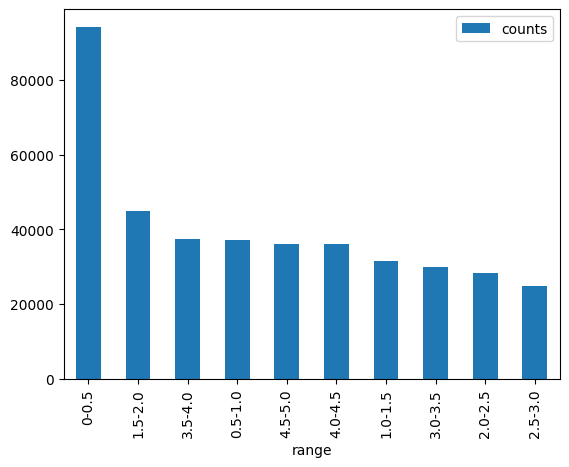

In [6]:
range_counts = train_df['range'].value_counts().reset_index()
range_counts.columns = ['range', 'counts']
range_counts.sort_values(by="range")
print(range_counts)

range_counts.plot(x='range', y='counts', kind='bar')
plt.show()

In [7]:
def gen_x_and_y(temp_data):
    X = temp_data.drop(columns =['SWE (in)', "range"], axis=1)
    y = temp_data['SWE (in)']

    scaler = StandardScaler()
    X[continuous_features] = scaler.fit_transform(X[continuous_features])
    X_tensor = torch.tensor(X.values, dtype=torch.float32)
    y_tensor = torch.tensor(y.values, dtype=torch.float32)
    return X_tensor, y_tensor

X_train_tensor, y_train_tensor = gen_x_and_y(train_df)
X_test_tensor, y_test_tensor = gen_x_and_y(test_df)

In [8]:
# categorical_features = [' lat','lon']
# continuous_features = ['month','Precip Accum SoD (in)','Air Temp Avg (F)','Air Temp Max (F)','Air Temp Obs SoD (F)','Air Temp Min (F)',
#                 'Precip Month-to-Date SoD (in)','Precip Inc (in)','Depth SoD (in)','Precip Inc Snow-adj (in)']

# for feature in categorical_features:
#     le = LabelEncoder()
#     data[feature] = le.fit_transform(data[feature])

# X = data.drop(columns =['SWE (in)', "range"], axis=1)
# y = data['SWE (in)']

# scaler = StandardScaler()
# X[continuous_features] = scaler.fit_transform(X[continuous_features])

# t_s = 0.2
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=t_s, random_state=42)

# X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
# y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
# X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
# y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [9]:
temp = 'cuda' if torch.cuda.is_available() else 'cpu'
device = torch.device(temp)
print("Using " + temp)

Using cuda


In [10]:
class SnotelMLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(SnotelMLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        # ugh = next(model.parameters()).device
        # print(f"Model is on device: {ugh}")

        x = x.to(device)
        # print("Tensor is on device:" + str(x.get_device()))
        return self.model(x)

#    def forward(self, x):
#       x = self.dropout(self.relu(self.bn1(self.fc1(x))))
#        x = self.dropout(self.relu(self.bn2(self.fc2(x))))
#        x = self.dropout(self.relu(self.bn3(self.fc3(x))))
#        x = self.dropout(self.relu(self.bn4(self.fc4(x))))
#        x = self.fc5(x)
#        return x

In [11]:
input_dim = X_train_tensor.shape[1]
output_dim = 1

learning_rate=0.001
b_s = 64

model = SnotelMLP(input_dim, output_dim).to(device)

loss_function = nn.MSELoss()#SmoothL1Loss()  # Better for regression with noise
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

# Dataloader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=b_s, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=b_s, shuffle=False)



In [12]:
device = next(model.parameters()).device
print(f"Model is on device: {device}")

Model is on device: cuda:0


In [13]:
# Training loop
num_epochs = 100
best_loss = float('inf')
patience = 10
epochs_since_improvement = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs).squeeze(1).to(device)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    # Validation
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs).squeeze(1).to(device)
            loss = loss_function(outputs, labels)
            test_loss += loss.item()

    avg_test_loss = test_loss / len(test_loader)
   # print(f"Test Loss after Epoch {epoch+1}: {avg_test_loss:.4f}")
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_loss:.4f}, Test Loss: {avg_test_loss:.4f}")


    scheduler.step(avg_test_loss)

    # Early stopping
    if avg_test_loss < best_loss:
        best_loss = avg_test_loss
        epochs_since_improvement = 0
    else:
        epochs_since_improvement += 1

    if epochs_since_improvement >= patience:
        print("Early stopping triggered.")
        break

Epoch [1/100], Train Loss: 0.4634, Test Loss: 1.8898
Epoch [2/100], Train Loss: 0.1741, Test Loss: 1.7031
Epoch [3/100], Train Loss: 0.1459, Test Loss: 0.8120
Epoch [4/100], Train Loss: 0.1287, Test Loss: 0.3513
Epoch [5/100], Train Loss: 0.1195, Test Loss: 0.2025
Epoch [6/100], Train Loss: 0.1109, Test Loss: 0.5110
Epoch [7/100], Train Loss: 0.1062, Test Loss: 0.9525
Epoch [8/100], Train Loss: 0.1013, Test Loss: 0.7064
Epoch [9/100], Train Loss: 0.0906, Test Loss: 0.6709
Epoch [10/100], Train Loss: 0.0882, Test Loss: 0.5477
Epoch [11/100], Train Loss: 0.0877, Test Loss: 0.6474
Epoch [12/100], Train Loss: 0.0827, Test Loss: 0.7851
Epoch [13/100], Train Loss: 0.0823, Test Loss: 0.5036
Epoch [14/100], Train Loss: 0.0815, Test Loss: 0.6355
Epoch [15/100], Train Loss: 0.0789, Test Loss: 0.8561
Early stopping triggered.


In [14]:
model.eval()
predictions = []
true_values = []

#with torch.no_grad():
#    predictions = model(X_test_tensor).squeeze().numpy()  # Get predictions as NumPy array
#    true_values = y_test_tensor.numpy()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs).squeeze(1)
        predictions.extend(outputs.cpu().numpy())
        true_values.extend(labels.cpu().numpy())

predictions = np.array(predictions)
true_values = np.array(true_values)

r2 = r2_score(true_values, predictions)
print(f"R² Score on Test Data: {r2:.4f}")

mae = mean_absolute_error(true_values, predictions)
print(f"MAE: {mae:.4f}")

R² Score on Test Data: 0.4278
MAE: 0.8715


In [15]:
# generate binned predictions (for classification metrics like f1 score)
def get_binned_y_values(y_values, bins, bin_labels):
    temp = pd.DataFrame({"cont_value": y_values})
    df_with_bins = add_labels(temp, bins, bin_labels, "cont_value")
    return df_with_bins["range"]

predictions_binned = get_binned_y_values(predictions, bins, bin_labels)
true_values_binned = get_binned_y_values(true_values, bins, bin_labels)

# calculate f1 score
f1 = f1_score(true_values_binned, predictions_binned, average="macro")
print(f"F1 Score: {f1}")

F1 Score: 0.026190365450049623


In [16]:
# Plot
# plt.figure(figsize=(10, 6))
# plt.plot(true_values[0:20], label='Ground Truth', color='blue')
# plt.plot(predictions[0:20], label='Predictions', color='red', alpha=0.7)
# plt.xlabel('Samples')
# plt.ylabel('Log(SWE (in))')
# plt.title('Predictions vs Ground Truth')
# plt.legend()
# plt.grid(True)
# plt.show()

In [17]:
# Plot
# plt.figure(figsize=(10, 6))
# plt.plot(np.expm1(true_values), label='Ground Truth', color='blue')
# plt.plot(np.expm1(predictions), label='Predictions', color='red', alpha=0.7)
# plt.xlabel('Samples')
# plt.ylabel('SWE (in)')
# plt.title('Predictions vs Ground Truth')
# plt.legend()
# plt.grid(True)
# plt.show()

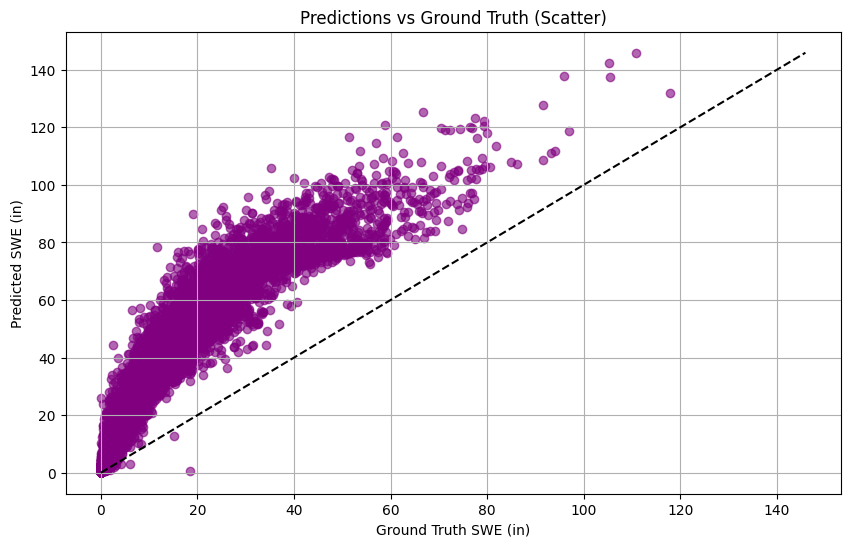

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(np.expm1(true_values), np.expm1(predictions), alpha=0.6, color='purple')
plt.xlabel('Ground Truth SWE (in)')
plt.ylabel('Predicted SWE (in)')
plt.title('Predictions vs Ground Truth (Scatter)')
plt.grid(True)
plt.plot([0, max(np.expm1(true_values).max(), np.expm1(predictions).max())], 
         [0, max(np.expm1(true_values).max(), np.expm1(predictions).max())], 
         color='black', linestyle='--')  # 1:1 reference line
plt.show()